In [3]:
!pip install matplotlib seaborn

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# Plotting Configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Configuration
BASE_DATA_PATH = "/Users/rishitkar/Desktop/MLOmics/Main_Dataset/Classification_datasets/"
OUTPUT_ROOT = "./processed_multicancer"

# Target Cancer Types
CANCER_TYPES = ["GS-BRCA", "GS-COAD", "GS-GBM", "GS-LGG", "GS-OV"]

if not os.path.exists(OUTPUT_ROOT):
    os.makedirs(OUTPUT_ROOT)

print("Configuration Loaded.")
print(f"Target Cancers: {CANCER_TYPES}")
print(f"Source Path: {BASE_DATA_PATH}")
print(f"Output Path: {OUTPUT_ROOT}")


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Configuration Loaded.
Target Cancers: ['GS-BRCA', 'GS-COAD', 'GS-GBM', 'GS-LGG', 'GS-OV']
Source Path: /Users/rishitkar/Desktop/MLOmics/Main_Dataset/Classification_datasets/
Output Path: ./processed_multicancer


# Helper Functions(File Detection and Cleaning)

### This cell defines the robust logic for finding files and cleaning the data (dropping 100% NaN columns, imputing, and removing zero-variance features).

In [4]:
def get_cancer_files(cancer_path):
    """
    Auto-detects relevant files in the directory based on rules:
    - Omics files must end with '_top.csv' (case insensitive check for type)
    - Label file must end with '_num.csv'
    """
    files_found = {'omics': {}, 'label': None}
    
    if not os.path.exists(cancer_path):
        raise FileNotFoundError(f"Directory not found: {cancer_path}")
        
    all_files = os.listdir(cancer_path)
    
    #  Identify Label File
    label_candidates = [f for f in all_files if f.endswith('num.csv')]
    if not label_candidates:
        raise FileNotFoundError(f"No label file (*num.csv) found in {cancer_path}")
    files_found['label'] = label_candidates[0]
    
    #  Identify Omics Files
    keywords = {
        'mRNA': ['mRNA', 'mrna'],
        'miRNA': ['miRNA', 'mirna'],
        'CNV': ['CNV', 'cnv'],
        'Methy': ['Methy', 'methy', 'Methylation']
    }
    
    for omic_key, search_terms in keywords.items():
        for f in all_files:
            # Strict check: Must end with 'top.csv' AND contain keyword
            if f.endswith('top.csv') and any(term in f for term in search_terms):
                files_found['omics'][omic_key] = f
                break
                
    return files_found

def clean_dataframe(df, name):
    """
    Executes cleaning pipeline:
    1. Drops columns containing only NaN values (100% missing).
    2. Imputes remaining NaN values with 0.
    3. Removes zero-variance (constant) features.
    4. Standardizes features (mean=0, std=1).
    """
    print(f"    Processing {name} | Initial Shape: {df.shape}")
    
    #  Drop 100% NaN columns
    df = df.dropna(axis=1, how='all')
    
    #  Impute remaining NaNs
    if df.isna().sum().sum() > 0:
        imp = SimpleImputer(strategy='constant', fill_value=0)
        # Convert back to DataFrame to preserve columns for VarianceThreshold
        df_vals = imp.fit_transform(df)
        df = pd.DataFrame(df_vals, index=df.index, columns=df.columns)

    #  Variance Threshold (Remove constant features)
    sel = VarianceThreshold(threshold=0.0)
    try:
        sel.fit(df)
        df = df.loc[:, sel.get_support()]
    except ValueError:
        pass # Keep original if selection fails
        
    #  Scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df).astype(np.float32)
    
    print(f"    Final Shape: {X_scaled.shape}")
    return X_scaled


# Main Processing Loop

This iterates through GS-BRCA, GS-COAD, etc., processes them, and saves the .npy files into separate folders.



In [7]:
for cancer in CANCER_TYPES:
    print(f"\n[START] Processing Cancer Type: {cancer}")
    
    # Define Paths
    # We look inside the 'Top' folder as per structure
    cancer_data_path = os.path.join(BASE_DATA_PATH, cancer, "Top")
    cancer_output_path = os.path.join(OUTPUT_ROOT, cancer)
    
    if not os.path.exists(cancer_output_path):
        os.makedirs(cancer_output_path)
        
    try:
        #  Identify Files
        files_map = get_cancer_files(cancer_data_path)
        print(f"  Label File: {files_map['label']}")
        print(f"  Omics Files: {list(files_map['omics'].keys())}")
        
        #  Load and Transpose Data
        data_dict = {}
        patient_ids_list = []
        
        for omic, filename in files_map['omics'].items():
            path = os.path.join(cancer_data_path, filename)
            
            # Load and Transpose
            df = pd.read_csv(path, index_col=0).T
            
            # Force string indices/columns to prevent type errors
            df.index = df.index.astype(str)
            df.columns = df.columns.astype(str)
            
            data_dict[omic] = df
            patient_ids_list.append(set(df.index))
            
        #  Align Patient IDs
        common_patients = sorted(list(set.intersection(*patient_ids_list)))
        print(f"  Alignment: {len(common_patients)} common patients found.")
        
        #  Process Labels
        label_path = os.path.join(cancer_data_path, files_map['label'])
        labels_df = pd.read_csv(label_path)
        
        # Assign Patient IDs (assuming order matches mRNA file)
        ref_patients = data_dict['mRNA'].index.tolist()
        
        if len(labels_df) != len(ref_patients):
             print(f"  WARNING: Label count ({len(labels_df)}) != mRNA Patient count ({len(ref_patients)}).")
             
        labels_df.index = ref_patients
        if 'Label' in labels_df.columns:
            labels_df.rename(columns={'Label': 'target'}, inplace=True)
            
        # Filter Labels to Common Patients
        aligned_labels = labels_df.loc[common_patients]
        
        #  Clean and Save Omics Data
        for omic, df in data_dict.items():
            df_aligned = df.loc[common_patients]
            X_clean = clean_dataframe(df_aligned, omic)
            
            save_file = os.path.join(cancer_output_path, f"{omic}_processed.npy")
            np.save(save_file, X_clean)
            
        #  Save Labels
        lbl_arr = aligned_labels['target'].values.astype(np.int64)
        np.save(os.path.join(cancer_output_path, "labels.npy"), lbl_arr)
        
        print(f"  [COMPLETED] {cancer} processed successfully.")
        
    except Exception as e:
        print(f"  [ERROR] Failed processing {cancer}: {str(e)}")



[START] Processing Cancer Type: GS-BRCA
  Label File: 54814634_BRCA_label_num.csv
  Omics Files: ['mRNA', 'miRNA', 'CNV', 'Methy']
  Alignment: 671 common patients found.
    Processing mRNA | Initial Shape: (671, 5000)
    Final Shape: (671, 5000)
    Processing miRNA | Initial Shape: (671, 366)
    Final Shape: (671, 200)
    Processing CNV | Initial Shape: (671, 5000)
    Final Shape: (671, 5000)
    Processing Methy | Initial Shape: (671, 5000)
    Final Shape: (671, 5000)
  [COMPLETED] GS-BRCA processed successfully.

[START] Processing Cancer Type: GS-COAD
  Label File: 54814562_COAD_label_num.csv
  Omics Files: ['mRNA', 'miRNA', 'CNV', 'Methy']
  Alignment: 260 common patients found.
    Processing mRNA | Initial Shape: (260, 5000)
    Final Shape: (260, 5000)
    Processing miRNA | Initial Shape: (260, 200)
    Final Shape: (260, 200)
    Processing CNV | Initial Shape: (260, 5000)
    Final Shape: (260, 5000)
    Processing Methy | Initial Shape: (260, 5000)
    Final Shape: 

# Visualize Class Disribution


[VISUALIZATION] Generating summary plots for all processed datasets...

--- Visualizing GS-BRCA ---


/var/folders/9r/fjxy7zrn0jj7zcjz76fpx4mr0000gn/T/ipykernel_57418/986101735.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique, y=counts, palette="viridis", ax=ax1)


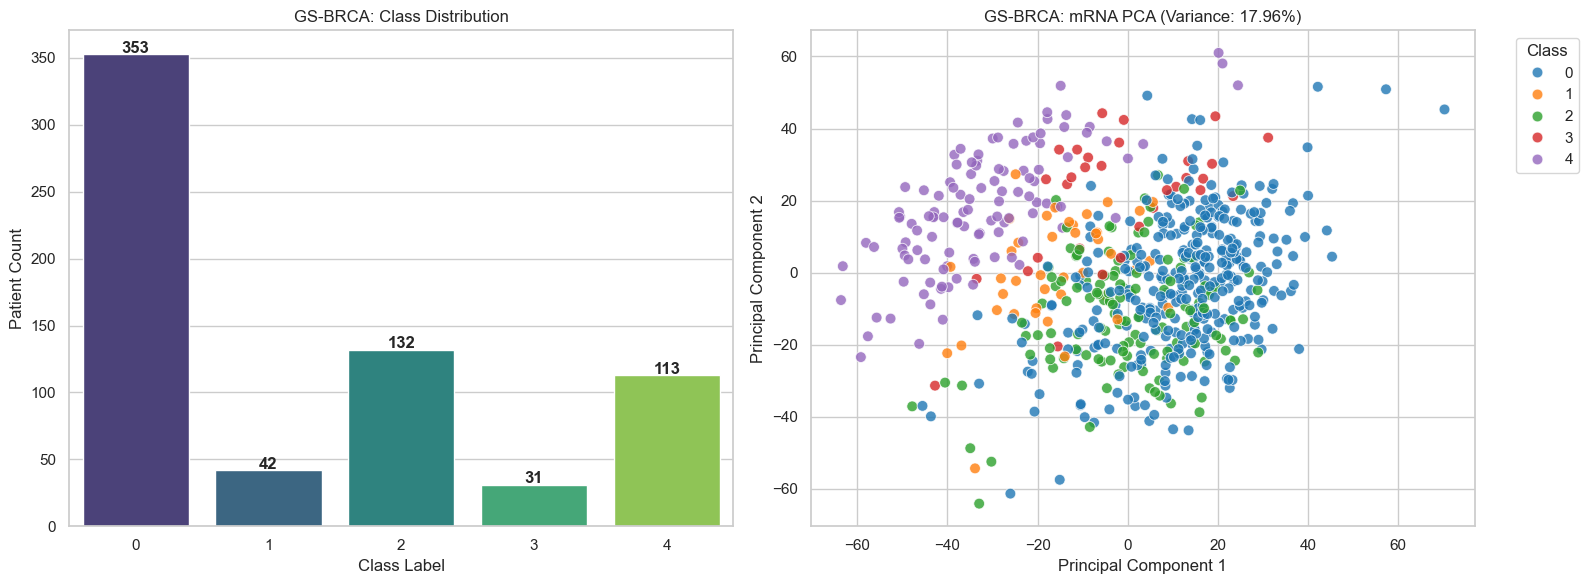

/var/folders/9r/fjxy7zrn0jj7zcjz76fpx4mr0000gn/T/ipykernel_57418/986101735.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique, y=counts, palette="viridis", ax=ax1)



--- Visualizing GS-COAD ---


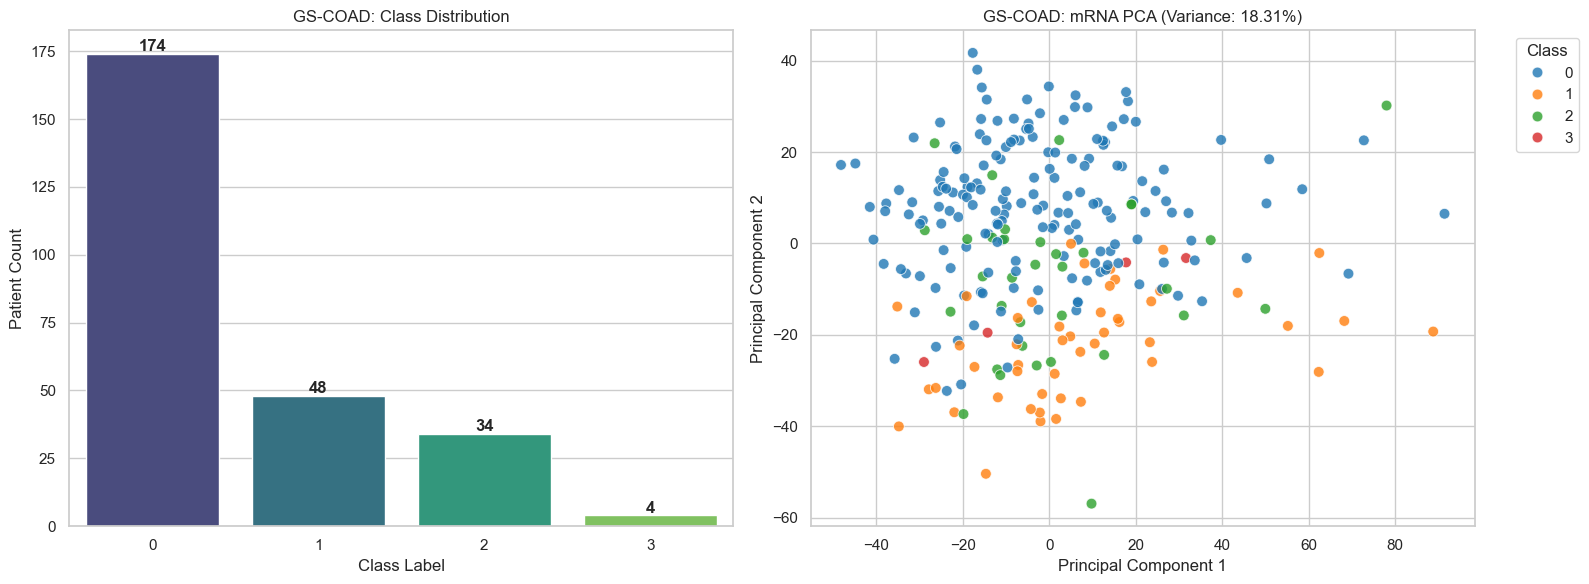


--- Visualizing GS-GBM ---


/var/folders/9r/fjxy7zrn0jj7zcjz76fpx4mr0000gn/T/ipykernel_57418/986101735.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique, y=counts, palette="viridis", ax=ax1)


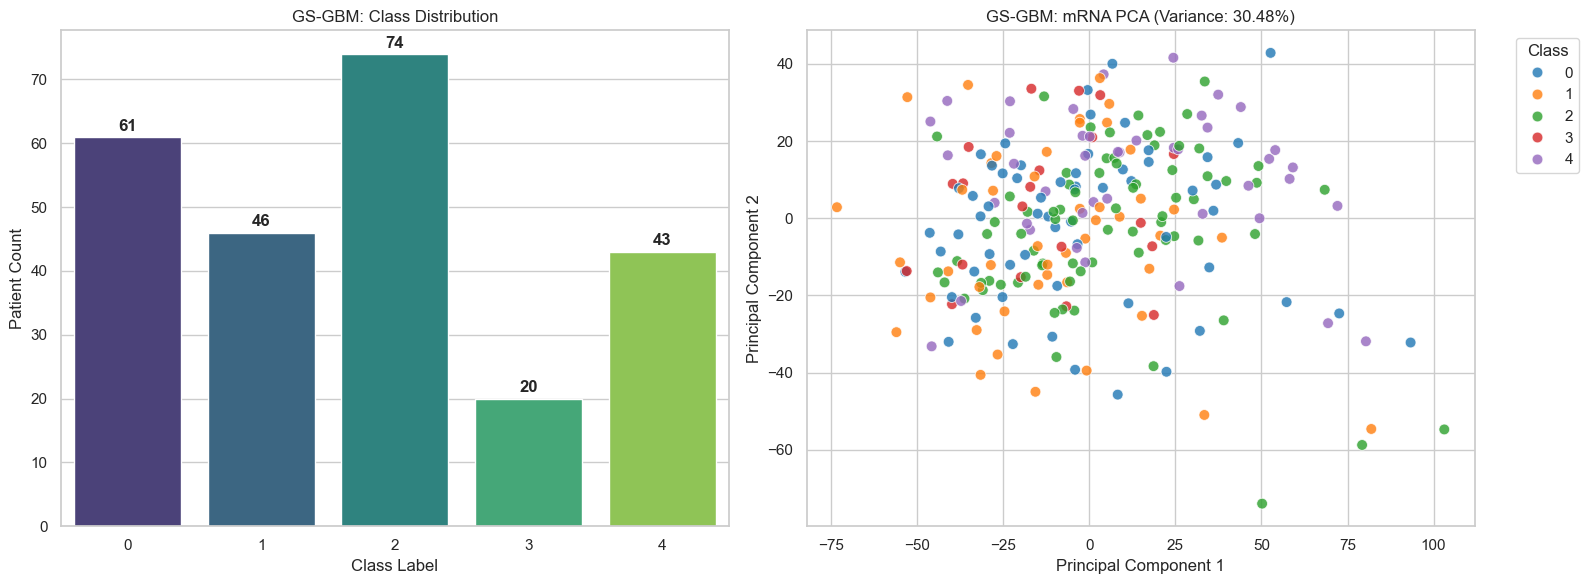

/var/folders/9r/fjxy7zrn0jj7zcjz76fpx4mr0000gn/T/ipykernel_57418/986101735.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique, y=counts, palette="viridis", ax=ax1)



--- Visualizing GS-LGG ---


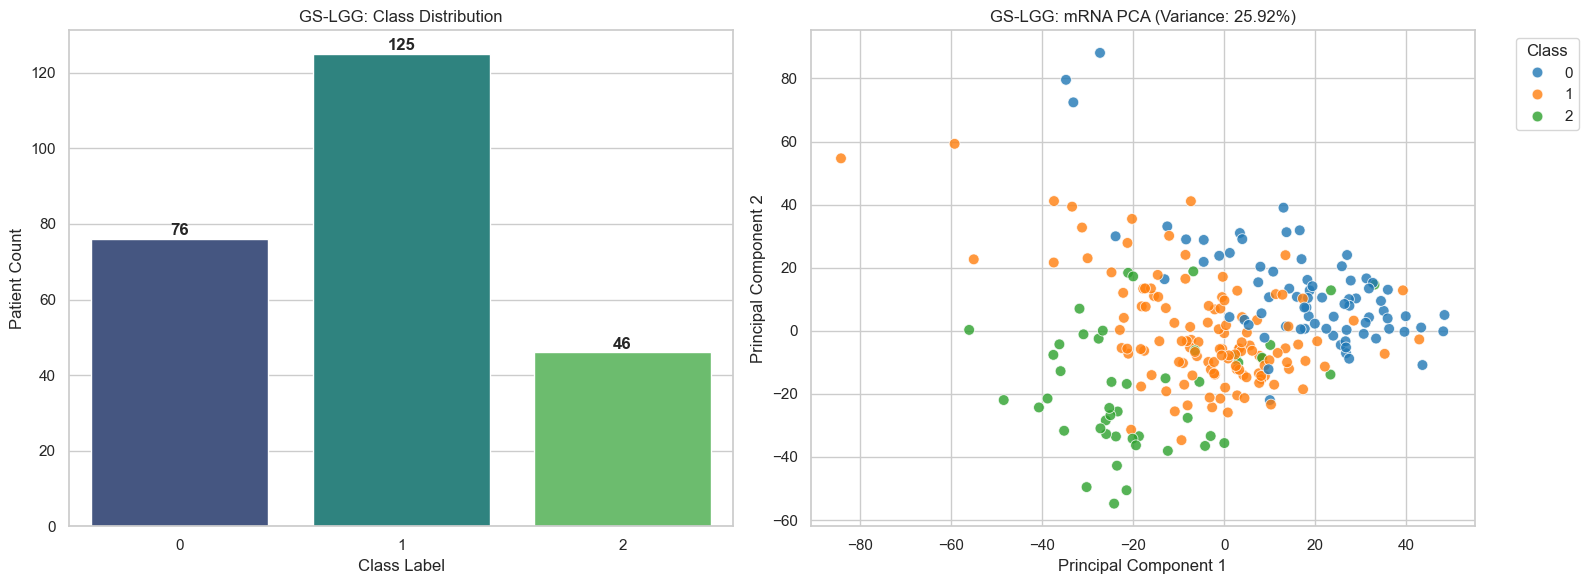


--- Visualizing GS-OV ---


/var/folders/9r/fjxy7zrn0jj7zcjz76fpx4mr0000gn/T/ipykernel_57418/986101735.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique, y=counts, palette="viridis", ax=ax1)


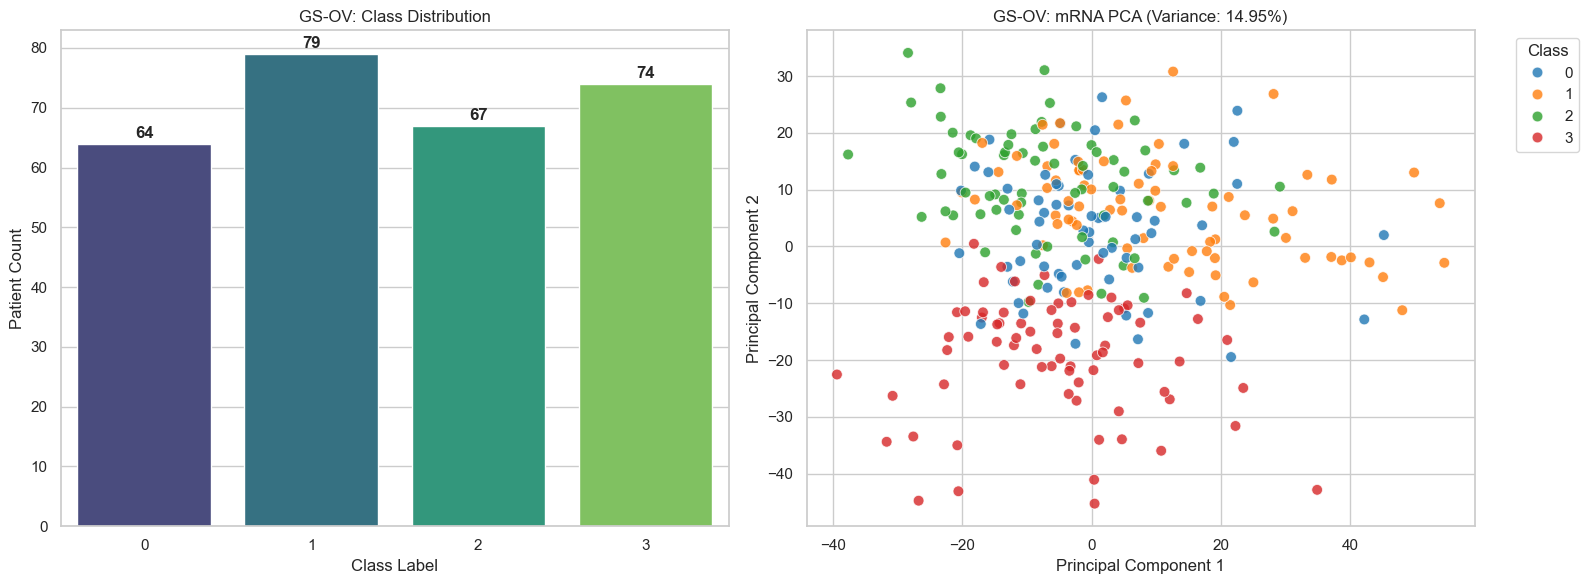

In [55]:
print("[VISUALIZATION] Generating summary plots for all processed datasets...")

for cancer in CANCER_TYPES:
    
    # Define Paths
    cancer_output_path = os.path.join(OUTPUT_ROOT, cancer)
    label_file = os.path.join(cancer_output_path, "labels.npy")
    mrna_file = os.path.join(cancer_output_path, "mRNA_processed.npy")
    
    # Skip if files missing (e.g., if processing failed)
    if not os.path.exists(label_file) or not os.path.exists(mrna_file):
        continue
        
    print(f"\n--- Visualizing {cancer} ---")
    
    # Load Data
    y = np.load(label_file)
    X = np.load(mrna_file)
    
    # Create Subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    #  Class Distribution
    unique, counts = np.unique(y, return_counts=True)
    sns.barplot(x=unique, y=counts, palette="viridis", ax=ax1)
    ax1.set_title(f"{cancer}: Class Distribution")
    ax1.set_xlabel("Class Label")
    ax1.set_ylabel("Patient Count")
    
    # Add count labels
    for i, v in enumerate(counts):
        ax1.text(i, v + 1, str(v), ha='center', fontweight='bold')
    
    #  PCA Projection (Data Quality Check)
    # We check if X has at least 2 columns before PCA
    if X.shape[1] >= 2:
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X)
        
        sns.scatterplot(
            x=X_pca[:, 0], y=X_pca[:, 1], 
            hue=y, palette="tab10", s=60, alpha=0.8, ax=ax2
        )
        var_explained = pca.explained_variance_ratio_.sum()
        ax2.set_title(f"{cancer}: mRNA PCA (Variance: {var_explained:.2%})")
        ax2.set_xlabel("Principal Component 1")
        ax2.set_ylabel("Principal Component 2")
        ax2.legend(title="Class", bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax2.text(0.5, 0.5, "Insufficient features for PCA", ha='center')
        
    plt.tight_layout()
    plt.show()
